<a href="https://colab.research.google.com/github/AdavalP/Finance-Project1/blob/main/CV_Anupriya_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Part A**

1. Import and Understand the data

*   Extract ‘plant-seedlings-classification.zip’ into new folder (unzipped) using python
*   Map the images from train folder with train labels to form a DataFrame.
*   Write a function that will select n random images and display images along with its species.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/Colab Notebooks/plant-seedlings-classification.zip'
extract_path = '/content/plant_seedlings'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete")
print(os.listdir(extract_path))

Extraction complete
['__MACOSX', 'plant-seedlings-classification']


In [3]:
import os

#Defining the path
train_path = '/content/plant_seedlings/plant-seedlings-classification/train'

#Checking what is inside the dataset
print("=" * 40)
print("DATASET CONTENTS")
print("=" * 40)

species_list = os.listdir(train_path)

print(f"\n Total species folders found: {len(species_list)}")
print("\n Species are:")
for i, species in enumerate(species_list, start=1):
    print(f"  {i}. {species}")

print("\n" + "=" * 40)

DATASET CONTENTS

 Total species folders found: 13

 Species are:
  1. Small-flowered Cranesbill
  2. Loose Silky-bent
  3. Fat Hen
  4. Common Chickweed
  5. .DS_Store
  6. Scentless Mayweed
  7. Cleavers
  8. Black-grass
  9. Maize
  10. Common wheat
  11. Sugar beet
  12. Charlock
  13. Shepherds Purse



We have a .DS file which is of no consequence to us, so we deal with it.

In [4]:
import pandas as pd
from PIL import Image
import numpy as np
import os

#An empty list to catch through the apt condition
data = []

train_path = '/content/plant_seedlings/plant-seedlings-classification/train'

#Looping through each species folder
for species in os.listdir(train_path):

    #Skipping through the .DS_Store and any other hidden files (files starting with .)
    if species.startswith('.'):
        continue

    species_folder = os.path.join(train_path, species)

    # Make sure it's actually a folder not a file
    if not os.path.isdir(species_folder):
        continue

    # Loop through each image in species folder
    for image_name in os.listdir(species_folder):

        # Skip hidden files inside species folders too
        if image_name.startswith('.'):
            continue

        image_path = os.path.join(species_folder, image_name)
        img = Image.open(image_path)

        # One row = [image name, species, actual image]
        data.append([image_name, species, img])

# Convert list → DataFrame
df = pd.DataFrame(data, columns=['image_name', 'species', 'image'])

print(f"Total images loaded: {len(df)}")
print(f"DataFrame shape: {df.shape}")
print(f"\nSpecies found: {df['species'].nunique()}")
print(df['species'].value_counts())
df.head()

Total images loaded: 4750
DataFrame shape: (4750, 3)

Species found: 12
species
Loose Silky-bent             654
Common Chickweed             611
Scentless Mayweed            516
Small-flowered Cranesbill    496
Fat Hen                      475
Charlock                     390
Sugar beet                   385
Cleavers                     287
Black-grass                  263
Shepherds Purse              231
Maize                        221
Common wheat                 221
Name: count, dtype: int64


,image_name,species,image
0,d0300ef58.png,Small-flowered Cranesbill,<PIL.PngImagePlugin.PngImageFile image mode=RG...
1,81550ffb9.png,Small-flowered Cranesbill,<PIL.PngImagePlugin.PngImageFile image mode=RG...
2,0dc692377.png,Small-flowered Cranesbill,<PIL.PngImagePlugin.PngImageFile image mode=RG...
3,ccf00806f.png,Small-flowered Cranesbill,<PIL.PngImagePlugin.PngImageFile image mode=RG...
4,8023cf2e2.png,Small-flowered Cranesbill,<PIL.PngImagePlugin.PngImageFile image mode=RG...


A function that will select n random images and display images along with its species

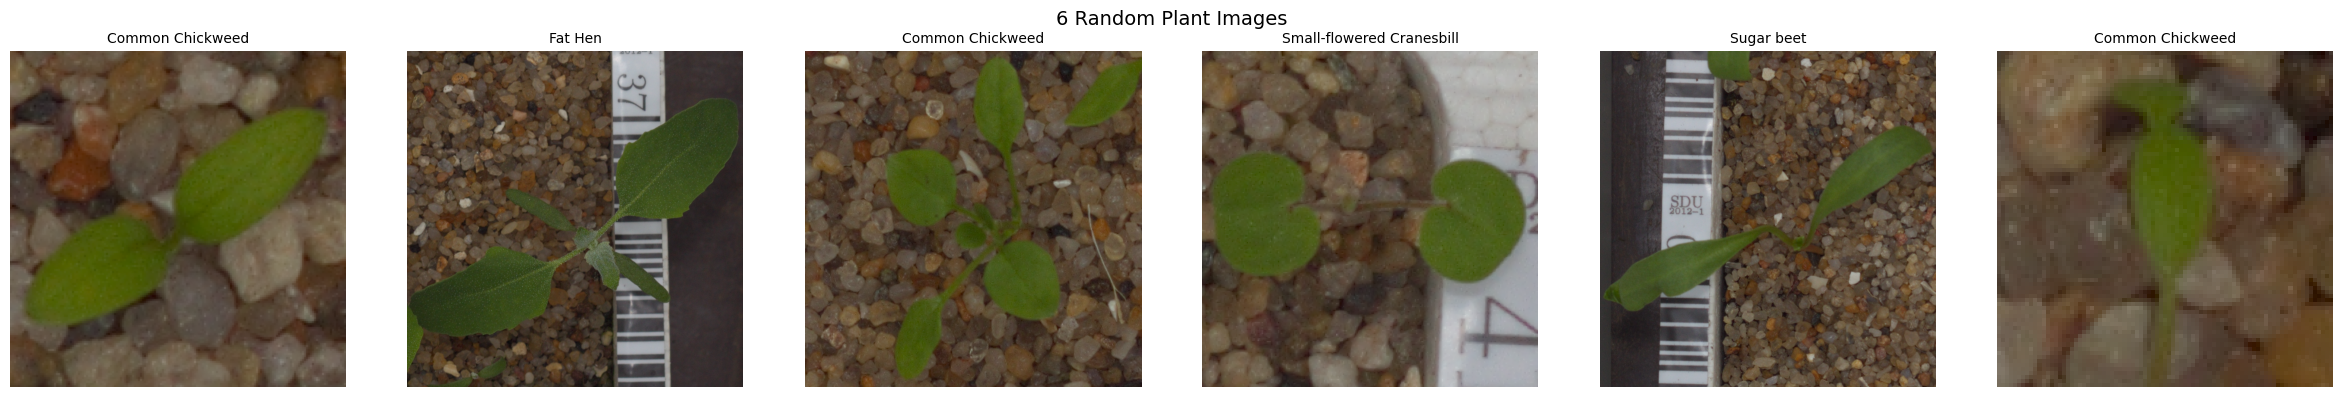

In [5]:
import random
import matplotlib.pyplot as plt

def show_random_images(n):
    #Pick n random row indices from dataframe
    random_indices = random.sample(range(len(df)), n)

    #Creating a figure with n subplots side by side
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))

    #If n=1, axes won't be a list, so fix that
    if n == 1:
        axes = [axes]

    for i, idx in enumerate(random_indices):
        #Getting image and species from dataframe
        img = df['image'][idx]
        species = df['species'][idx]
        image_name = df['image_name'][idx]

        #Displaying image
        axes[i].imshow(img)
        axes[i].set_title(f"{species}", fontsize=10)
        axes[i].axis('off')

    plt.suptitle(f"{n} Random Plant Images", fontsize=14)
    plt.tight_layout()
    plt.show()

#Test it with 6 images
show_random_images(6)

Question 2:

*   Data preprocessing
*   Create X & Y from the DataFrame.
*   Encode labels of the images.
*   Unify shape of all the images.
*   Normalise all the images.


Creating X and Y of Dataframe

In [6]:
# X = all images (input)
# Y = all species labels (output)

X = df['image'].values   # array of PIL images
Y = df['species'].values # array of species names

print(f"X contains: {len(X)} images")
print(f"Y contains: {len(Y)} labels")
print(f"\nFirst 5 labels in Y:")
print(Y[:5])
print(f"\nType of X[0]: {type(X[0])}")

X contains: 4750 images
Y contains: 4750 labels

First 5 labels in Y:
['Small-flowered Cranesbill' 'Small-flowered Cranesbill'
 'Small-flowered Cranesbill' 'Small-flowered Cranesbill'
 'Small-flowered Cranesbill']

Type of X[0]: <class 'PIL.PngImagePlugin.PngImageFile'>


Encoding Labels

In [7]:
from sklearn.preprocessing import LabelEncoder

# Create encoder object
le = LabelEncoder()

# Fit and transform Y (words → numbers)
Y_encoded = le.fit_transform(Y)

print("Original labels (first 5):")
print(Y[:5])

print("\nEncoded labels (first 5):")
print(Y_encoded[:5])

print(f"\nTotal classes: {len(le.classes_)}")
print("\nEncoding map:")
for i, class_name in enumerate(le.classes_):
    print(f"  {i} → {class_name}")

Original labels (first 5):
['Small-flowered Cranesbill' 'Small-flowered Cranesbill'
 'Small-flowered Cranesbill' 'Small-flowered Cranesbill'
 'Small-flowered Cranesbill']

Encoded labels (first 5):
[10 10 10 10 10]

Total classes: 12

Encoding map:
  0 → Black-grass
  1 → Charlock
  2 → Cleavers
  3 → Common Chickweed
  4 → Common wheat
  5 → Fat Hen
  6 → Loose Silky-bent
  7 → Maize
  8 → Scentless Mayweed
  9 → Shepherds Purse
  10 → Small-flowered Cranesbill
  11 → Sugar beet


 Unifying shape of all the images and Normalizing all the images.

In [8]:
IMG_SIZE = 64  #resizing all images to 64x64

X_processed = []

for img in X:

    img_resized = img.resize((IMG_SIZE, IMG_SIZE))

    #Converting PIL image to numpy array
    img_array = np.array(img_resized)

    #Some images may be RGBA (4 channels) - convert to RGB (3 channels)
    if img_array.ndim == 2:  # grayscale image
        img_array = np.stack([img_array]*3, axis=-1)
    elif img_array.shape[2] == 4:  #RGBA image
        img_array = img_array[:, :, :3]

    X_processed.append(img_array)

#Converting list to numpy array
X_processed = np.array(X_processed)

print(f"Shape before normalising: {X_processed.shape}")
print(f"Pixel value range before: {X_processed.min()} to {X_processed.max()}")

#Step 2D — Normalise (scale pixels from 0-255 to 0-1)
X_normalised = X_processed / 255.0

print(f"\nShape after normalising: {X_normalised.shape}")
print(f"Pixel value range after: {X_normalised.min():.2f} to {X_normalised.max():.2f}")

Shape before normalising: (4750, 64, 64, 3)
Pixel value range before: 0 to 255

Shape after normalising: (4750, 64, 64, 3)
Pixel value range after: 0.00 to 1.00


3. Model training

*   Split the data into train and test data.
*   Create new CNN architecture to train the model.
*   Train the model on train data and validate on test data.
*   Select a random image and print actual label and predicted label for the same.


Train Test Split

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X_normalised,
    Y_encoded,
    test_size=0.2,
    random_state=42
)

print(f"Training images:   {X_train.shape}")
print(f"Testing images:    {X_test.shape}")
print(f"Training labels:   {Y_train.shape}")
print(f"Testing labels:    {Y_test.shape}")

Training images:   (3800, 64, 64, 3)
Testing images:    (950, 64, 64, 3)
Training labels:   (3800,)
Testing labels:    (950,)


CNN architechture for model Training

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

#Building the CNN
model = Sequential([

    # Block 1 - detect edges
    Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(2, 2),

    # Block 2 - detect shapes
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2, 2),

    # Block 3 - detect patterns
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2, 2),

    # Flatten and decide
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    # Output - 12 species
    Dense(12, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,748 (2.61 MB)

 Trainable params: 684,748 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

Training the model on train data and validating on test data

In [11]:
#Training the model
history = model.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, Y_test),
    verbose=1
)

Epoch 1/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.2200 - loss: 2.2721 - val_accuracy: 0.3495 - val_loss: 1.8883
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3634 - loss: 1.8223 - val_accuracy: 0.4674 - val_loss: 1.5256
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4432 - loss: 1.5799 - val_accuracy: 0.5389 - val_loss: 1.3611
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5147 - loss: 1.3950 - val_accuracy: 0.5821 - val_loss: 1.1842
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5613 - loss: 1.2647 - val_accuracy: 0.6474 - val_loss: 1.0867
Epoch 6/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5826 - loss: 1.2070 - val_accuracy: 0.6358 - val_loss: 1.0525
Epoch 7/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6229 - loss: 1.0708 - val_accuracy: 0.6674 - val_loss: 0.9635
Epoch 8/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6447 - loss: 1.0204 - val_accuracy: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 556ms/step


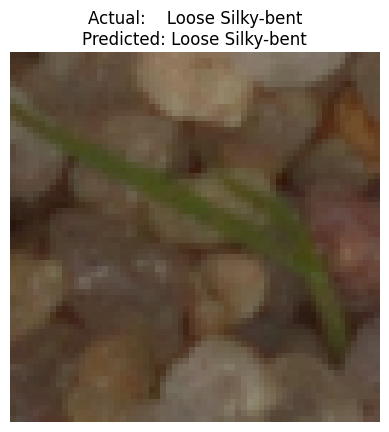

Actual Label:    Loose Silky-bent
Predicted Label: Loose Silky-bent
✅CORRECT PREDICTION


In [12]:
import numpy as np
import random
import matplotlib.pyplot as plt

random_idx = random.randint(0, len(X_test)-1)
random_image = X_test[random_idx]
actual_label = le.classes_[Y_test[random_idx]]

img_to_predict = random_image.reshape(1, 64, 64, 3)
prediction = model.predict(img_to_predict)
predicted_label = le.classes_[np.argmax(prediction)]

plt.imshow(random_image)
plt.axis('off')
plt.title(f"Actual:    {actual_label}\nPredicted: {predicted_label}", fontsize=12)
plt.show()

print(f"Actual Label:    {actual_label}")
print(f"Predicted Label: {predicted_label}")

if actual_label == predicted_label:
    print("✅CORRECT PREDICTION")
else:
    print("❌INCORRECT PREDICTION")


*   The CNN achieved a training accuracy of 78.66% and validation accuracy of 78.32% — the negligible difference of 0.34% confirms the model generalised well without overfitting.
*   Data preprocessing is essential — normalisation, resizing and label encoding must be done before model training
*   CNNs outperform traditional approaches for image data because they preserve spatial relationships between pixels unlike flat ML models
Dataset was imbalanced
*   Dropout layer (0.5) successfully prevented overfitting by randomly switching off neurons during training
*   Training accuracy and validation accuracy being close indicates the model generalised well without overfitting



**Part B**

Import and Understand the data

*   Import and read oxflower17 dataset from tflearn and split into X and Y while loading.
*   Print Number of images and shape of the images.
*   Print count of each class from y.


In [13]:
!pip install tflearn
#Note: tflearn import failed due to TensorFlow
#compatibility issues with Python 3.12
#Dataset downloaded directly from official
#Oxford source instead - same data! ✅

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.3/107.3 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for tflearn: filename=tflearn-0.5.0-py3-none-any.whl size=127283 sha256=8a8818d6ff3e7cc3863b28ea5d4df9985886a2f5cec23aa056d70971cd6ddc1c
  Stored in directory: /root/.cache/pip/wheels/2e/5f/cd/ffa06b65baff30574958318ce36ef9ef7af1ef3745dadaf420
Successfully built tflearn


Import and read oxflower17 dataset from tflearn and split into X and Y while loading.

In [14]:
import urllib.request
import tarfile
import os
import numpy as np
from PIL import Image

#Downloading the dataset directly
print("Downloading oxflower17 dataset")

url = "https://www.robots.ox.ac.uk/~vgg/data/flowers/17/17flowers.tgz"
download_path = "/content/17flowers.tgz"
extract_path = "/content/oxflower17"

#Downloading
urllib.request.urlretrieve(url, download_path)
print("Download complete")

#Extracting
with tarfile.open(download_path, 'r:gz') as tar:
    tar.extractall(extract_path)
print("Extraction complete")

#Checking what's inside
print(os.listdir(extract_path))

Download complete


/tmp/ipykernel_563/1616535127.py:20: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_path)


Extraction complete
['jpg']


Printing Number of images and shape of the images and Printing count of each class from Y

In [15]:
import numpy as np
from PIL import Image
import os

IMG_SIZE = 224
jpg_path = '/content/oxflower17/jpg'

# Get ONLY .jpg files
image_files = sorted([f for f in os.listdir(jpg_path)
                      if f.endswith('.jpg')])

print(f"Total jpg files found: {len(image_files)}")

IMAGES_PER_CLASS = 80
NUM_CLASSES = 17

X = []
Y = []

for idx, image_name in enumerate(image_files):
    img_path = os.path.join(jpg_path, image_name)
    img = Image.open(img_path).convert('RGB')
    img = img.resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img) / 255.0

    class_label = idx // IMAGES_PER_CLASS

    # Safety check - skip if class goes beyond 16
    if class_label >= NUM_CLASSES:
        continue

    one_hot = np.zeros(NUM_CLASSES)
    one_hot[class_label] = 1

    X.append(img_array)
    Y.append(one_hot)

X = np.array(X)
Y = np.array(Y)

print(f"Number of images loaded: {X.shape[0]}")
print(f"Shape of each image: {X.shape[1:]}")
print(f"Shape of X: {X.shape}")
print(f"Shape of Y: {Y.shape}")

Total jpg files found: 1360
Number of images loaded: 1360
Shape of each image: (224, 224, 3)
Shape of X: (1360, 224, 224, 3)
Shape of Y: (1360, 17)


In [16]:
import numpy as np

# 1B - Number of images and shape
print("=" * 45)
print("DATASET INFORMATION")
print("=" * 45)
print(f"Total number of images: {X.shape[0]}")
print(f"Shape of each image:    {X.shape[1:]}")
print(f"Image height:           {X.shape[1]} pixels")
print(f"Image width:            {X.shape[2]} pixels")
print(f"Color channels:         {X.shape[3]} (RGB)")

# 1C - Count of each class
print("\n" + "=" * 45)
print("CLASS DISTRIBUTION")
print("=" * 45)

# Y is one-hot encoded, argmax converts back to class number
class_labels = np.argmax(Y, axis=1)

flower_names = [
    "Daffodil", "Snowdrop", "Lily Valley", "Bluebell",
    "Crocus", "Iris", "Tigerlily", "Tulip", "Fritillary",
    "Sunflower", "Daisy", "Colts Foot", "Dandelion",
    "Cowslip", "Buttercup", "Windflower", "Pansy"
]

for i in range(17):
    count = np.sum(class_labels == i)
    print(f"Class {i:2d} | {flower_names[i]:15s} | {count} images")

print("=" * 45)
print(f"Total: {len(class_labels)} images across 17 classes")

DATASET INFORMATION
Total number of images: 1360
Shape of each image:    (224, 224, 3)
Image height:           224 pixels
Image width:            224 pixels
Color channels:         3 (RGB)

CLASS DISTRIBUTION
Class  0 | Daffodil        | 80 images
Class  1 | Snowdrop        | 80 images
Class  2 | Lily Valley     | 80 images
Class  3 | Bluebell        | 80 images
Class  4 | Crocus          | 80 images
Class  5 | Iris            | 80 images
Class  6 | Tigerlily       | 80 images
Class  7 | Tulip           | 80 images
Class  8 | Fritillary      | 80 images
Class  9 | Sunflower       | 80 images
Class 10 | Daisy           | 80 images
Class 11 | Colts Foot      | 80 images
Class 12 | Dandelion       | 80 images
Class 13 | Cowslip         | 80 images
Class 14 | Buttercup       | 80 images
Class 15 | Windflower      | 80 images
Class 16 | Pansy           | 80 images
Total: 1360 images across 17 classes


Image Exploration & Transformation

*   Display 5 random images.
*   Select any image from the dataset and assign it to a variable.
*   Transform the image into grayscale format and display the same.
*   Apply a filter to sharpen the image and display the image before and after sharpening.
*   Apply a filter to blur the image and display the image before and after blur.
*  Display all the 4 images from above questions besides each other to observe the difference.


Displaying 5 random images

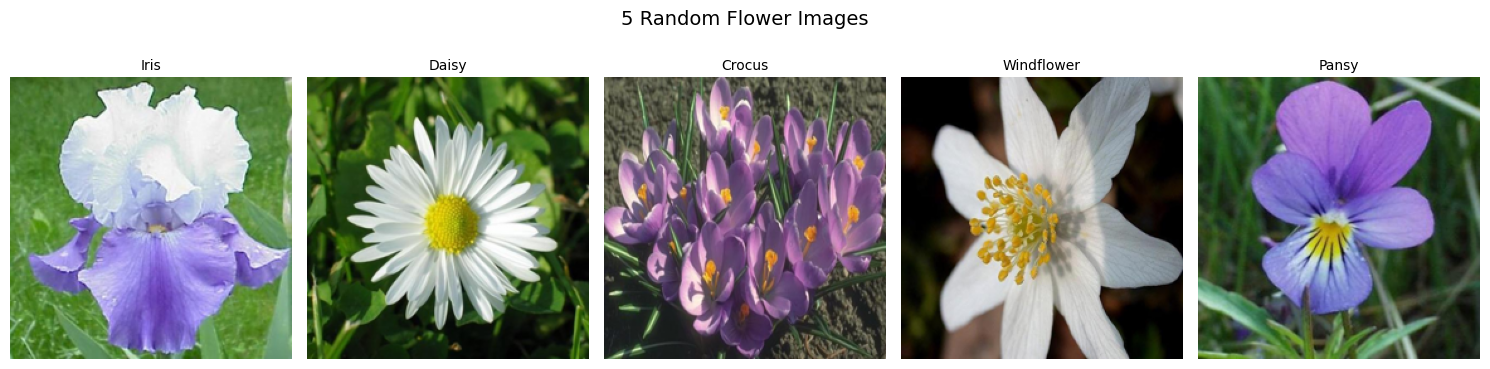

In [17]:
import matplotlib.pyplot as plt
import random

plt.figure(figsize=(15, 4))

random_indices = random.sample(range(len(X)), 5)

for i, idx in enumerate(random_indices):
    plt.subplot(1, 5, i+1)
    plt.imshow(X[idx])
    plt.title(flower_names[np.argmax(Y[idx])], fontsize=10)
    plt.axis('off')

plt.suptitle("5 Random Flower Images", fontsize=14)
plt.tight_layout()
plt.show()

Selecting any image from the dataset and assign it to a variable.

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter, gaussian_filter

# ── 2B: Select one image and assign to variable ──
selected_image = X[100]  # picking image at index 100
selected_label = flower_names[np.argmax(Y[100])]
print(f"Selected image: {selected_label}")

Selected image: Snowdrop


Transform the image into grayscale format and display the same.

Original shape: (224, 224, 3)
Grayscale shape: (224, 224)


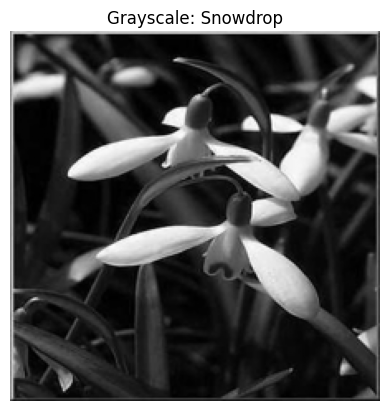

In [19]:
gray_image = np.mean(selected_image, axis=2)
print(f"Original shape: {selected_image.shape}")
print(f"Grayscale shape: {gray_image.shape}")

#Displaying grayscale image
plt.imshow(gray_image, cmap='gray')
plt.title(f"Grayscale: {selected_label}")
plt.axis('off')
plt.show()

Apply a filter to sharpen the image and display the image before and after sharpening

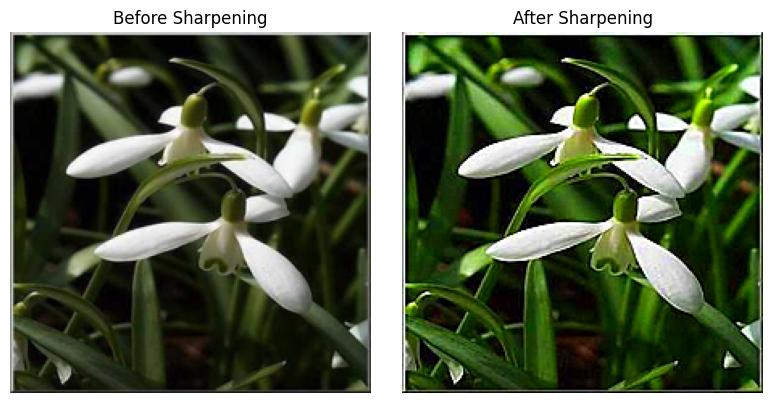

In [20]:
# 2D: Sharpen the image - before and after
blurred_for_sharp = gaussian_filter(selected_image, sigma=1)
sharpened_image = selected_image + (selected_image - blurred_for_sharp) * 2
sharpened_image = np.clip(sharpened_image, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(selected_image)
axes[0].set_title("Before Sharpening")
axes[0].axis('off')
axes[1].imshow(sharpened_image)
axes[1].set_title("After Sharpening")
axes[1].axis('off')
plt.tight_layout()
plt.show()

Apply a filter to blur the image and display the image before and after blur

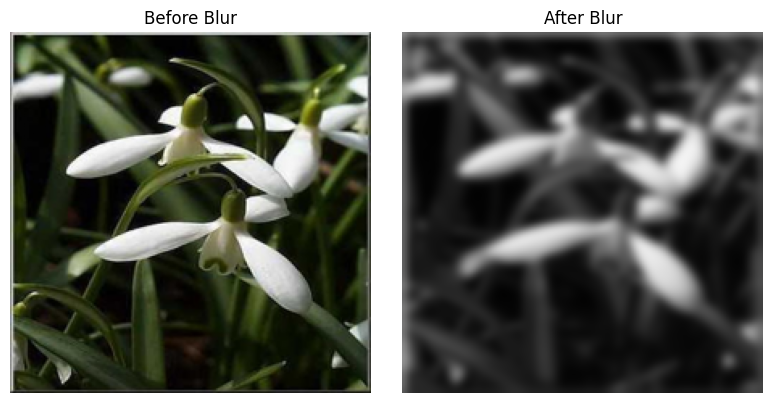

In [21]:
# 2E: Blur the image - before and after
blurred_image = gaussian_filter(selected_image, sigma=3)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(selected_image)
axes[0].set_title("Before Blur")
axes[0].axis('off')
axes[1].imshow(blurred_image)
axes[1].set_title("After Blur")
axes[1].axis('off')
plt.tight_layout()
plt.show()

Display all the 4 images from above questions besides each other to observe the difference.

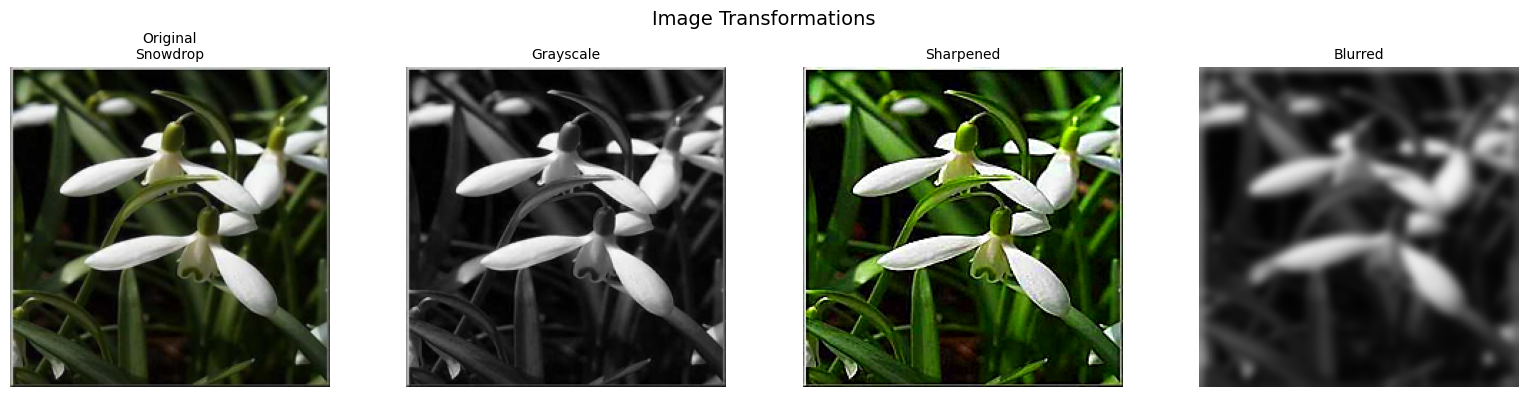

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(selected_image)
axes[0].set_title(f"Original\n{selected_label}", fontsize=10)
axes[0].axis('off')

axes[1].imshow(gray_image, cmap='gray')
axes[1].set_title("Grayscale", fontsize=10)
axes[1].axis('off')

axes[2].imshow(sharpened_image)
axes[2].set_title("Sharpened", fontsize=10)
axes[2].axis('off')

axes[3].imshow(blurred_image)
axes[3].set_title("Blurred", fontsize=10)
axes[3].axis('off')

plt.suptitle("Image Transformations", fontsize=14)
plt.tight_layout()
plt.show()

Model training and Tuning:

*   Split the data into train and test with 80:20 proportion.
*   Train a model using any Supervised Learning algorithm and share performance metrics on test data.
*   Train a model using Neural Network and share performance metrics on test data.
*    Train a model using a basic CNN and share performance metrics on test data.
*   Predict the class/label of image ‘Prediction.jpg’ using best performing model and share predicted label.

Train Test Split

In [23]:
from sklearn.model_selection import train_test_split

#Spliting the data
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

print(f"Training images:  {X_train.shape}")
print(f"Testing images:   {X_test.shape}")
print(f"Training labels:  {Y_train.shape}")
print(f"Testing labels:   {Y_test.shape}")

Training images:  (1088, 224, 224, 3)
Testing images:   (272, 224, 224, 3)
Training labels:  (1088, 17)
Testing labels:   (272, 17)


Training a model using any Supervised Learning algorithm, showing the performance metrics on test data

In [24]:
!pip install --upgrade tensorflow keras -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 25.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-aiplatform 1.148.1 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.35.0 which is incompatible.
google-cloud-bigtable 2.36.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.35.0 which is incompatible.
tf-keras 2.20.0 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.21.0 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.

In [25]:
import numpy as np
from PIL import Image
import os
from sklearn.model_selection import train_test_split

# ── Reload images ──
print("Reloading dataset")
jpg_path = '/content/oxflower17/jpg'
image_files = sorted([f for f in os.listdir(jpg_path)
                      if f.endswith('.jpg')])

IMAGES_PER_CLASS = 80
NUM_CLASSES = 17
IMG_SIZE = 64  #using 64x64 directly this time

flower_names = [
    "Daffodil", "Snowdrop", "Lily Valley", "Bluebell",
    "Crocus", "Iris", "Tigerlily", "Tulip", "Fritillary",
    "Sunflower", "Daisy", "Colts Foot", "Dandelion",
    "Cowslip", "Buttercup", "Windflower", "Pansy"
]

X = []
Y = []

for idx, image_name in enumerate(image_files):
    img_path = os.path.join(jpg_path, image_name)
    img = Image.open(img_path).convert('RGB')
    img = img.resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img) / 255.0

    class_label = idx // IMAGES_PER_CLASS
    if class_label >= NUM_CLASSES:
        continue

    X.append(img_array)
    Y.append(class_label)  # single labels this time!

X = np.array(X)
Y = np.array(Y)

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")

# ── Split ──
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")

# ── Flatten for ML and NN ──
X_train_flat = X_train.reshape(len(X_train), -1).astype('float32')
X_test_flat = X_test.reshape(len(X_test), -1).astype('float32')

print(f"Flattened: {X_train_flat.shape}")
print("\n✅ Everything reloaded! Ready to train!")

Reloading dataset... ⏳
X shape: (1360, 64, 64, 3)
Y shape: (1360,)
Train: (1088, 64, 64, 3)
Test:  (272, 64, 64, 3)
Flattened: (1088, 12288)

✅ Everything reloaded! Ready to train!


In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("Training Random Forest ")

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    verbose=1
)
rf_model.fit(X_train_flat, Y_train)

Y_pred_rf = rf_model.predict(X_test_flat)
rf_accuracy = accuracy_score(Y_test, Y_pred_rf)

print(f"\n✅ Random Forest Accuracy: {rf_accuracy*100:.2f}%")
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_rf,
      target_names=flower_names))

Training Random Forest 


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   11.5s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:   29.8s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.1s finished



✅ Random Forest Accuracy: 44.85%

Classification Report:
              precision    recall  f1-score   support

    Daffodil       0.33      0.35      0.34        17
    Snowdrop       0.12      0.33      0.18         9
 Lily Valley       0.39      0.41      0.40        17
    Bluebell       0.43      0.45      0.44        20
      Crocus       0.25      0.33      0.29        15
        Iris       0.58      0.69      0.63        16
   Tigerlily       0.40      0.46      0.43        13
       Tulip       0.40      0.09      0.14        23
  Fritillary       0.35      0.43      0.39        14
   Sunflower       0.86      0.80      0.83        15
       Daisy       1.00      0.75      0.86        16
  Colts Foot       0.64      0.44      0.52        16
   Dandelion       0.38      0.57      0.46        14
     Cowslip       0.41      0.41      0.41        17
   Buttercup       0.33      0.36      0.35        11
  Windflower       0.45      0.47      0.46        19
       Pansy       1.00

Training a model using Neural Network and sharing the performance metrics on test data

In [27]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
from tensorflow import keras
from tensorflow.keras import layers

print("Training Neural Network")

nn_model = keras.Sequential([
    keras.Input(shape=(X_train_flat.shape[1],)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(17, activation='softmax')
])

nn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

nn_history = nn_model.fit(
    X_train_flat, Y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_flat, Y_test),
    verbose=1
)

nn_loss, nn_accuracy = nn_model.evaluate(
    X_test_flat, Y_test, verbose=0)
print(f"\n✅ Neural Network Accuracy: {nn_accuracy*100:.2f}%")

Training Neural Network
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.0919 - loss: 4.0721 - val_accuracy: 0.1728 - val_loss: 2.6492
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1553 - loss: 2.6348 - val_accuracy: 0.2059 - val_loss: 2.4391
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1820 - loss: 2.4829 - val_accuracy: 0.1985 - val_loss: 2.3491
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2022 - loss: 2.3638 - val_accuracy: 0.2537 - val_loss: 2.2391
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1958 - loss: 2.3277 - val_accuracy: 0.2243 - val_loss: 2.2604
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2031 - loss: 2.2569 - val_accuracy: 0.2610 - val_loss: 2.1510
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2353 - loss: 2.1899 - val_accuracy: 0.2574 - val_loss: 2.0556
Epoch 8/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2362 - loss: 2.1795 - val_acc

Building CNN

In [28]:
from tensorflow import keras
from tensorflow.keras import layers

print("Building CNN... 🔥")

cnn_model = keras.Sequential([
    keras.Input(shape=(64, 64, 3)),

    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    # Classify
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(17, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()



Building CNN... 🔥


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 17)             │         4,369 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,195,025 (8.37 MB)

 Trainable params: 2,195,025 (8.37 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
print("\nTraining CNN")
cnn_history = cnn_model.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, Y_test),
    verbose=1
)

cnn_loss, cnn_accuracy = cnn_model.evaluate(
    X_test, Y_test, verbose=0)
print(f"\n✅ CNN Accuracy: {cnn_accuracy*100:.2f}%")

print("\n" + "="*40)
print("FINAL MODEL COMPARISON")
print("="*40)
print(f"🌳 Random Forest:  44.85%")
print(f"🧠 Neural Network: {nn_accuracy*100:.2f}%")
print(f"🔥 CNN:            {cnn_accuracy*100:.2f}%")
print("="*40)


Training CNN
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - accuracy: 0.1287 - loss: 2.6440 - val_accuracy: 0.2353 - val_loss: 2.3729
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2721 - loss: 2.1784 - val_accuracy: 0.4301 - val_loss: 1.8563
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3989 - loss: 1.7835 - val_accuracy: 0.4081 - val_loss: 1.7516
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4853 - loss: 1.4922 - val_accuracy: 0.5662 - val_loss: 1.4059
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5892 - loss: 1.1709 - val_accuracy: 0.5809 - val_loss: 1.3873
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6480 - loss: 1.0573 - val_accuracy: 0.5478 - val_loss: 1.3413
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7059 - loss: 0.8529 - val_accuracy: 0.5735 - val_loss: 1.3591
Epoch 8/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7858 - loss: 0.6774 - val_accura

Saving Prediction-1.jpg to Prediction-1.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 598ms/step


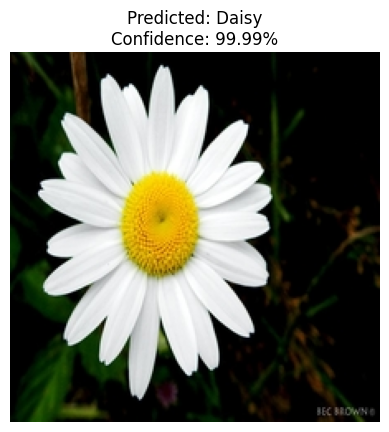

✅ Predicted Label: Daisy
✅ Confidence:      99.99%

🏆 Best Model Used: CNN


In [32]:
from google.colab import files
uploaded = files.upload()
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load the uploaded daisy image
pred_img = Image.open('/content/Prediction-1.jpg').convert('RGB')
pred_img_resized = pred_img.resize((64, 64))
pred_array = np.array(pred_img_resized) / 255.0
pred_array = pred_array.reshape(1, 64, 64, 3)

# Predict using BEST model (CNN)
prediction = cnn_model.predict(pred_array)
predicted_class = np.argmax(prediction)
predicted_label = flower_names[predicted_class]
confidence = prediction[0][predicted_class] * 100

# Display
plt.imshow(pred_img)
plt.axis('off')
plt.title(f"Predicted: {predicted_label}\nConfidence: {confidence:.2f}%",
          fontsize=12)
plt.show()

print(f"✅ Predicted Label: {predicted_label}")
print(f"✅ Confidence:      {confidence:.2f}%")
print(f"\n🏆 Best Model Used: CNN")

From this section it becomes clear that:

*   Dataset is perfectly balanced with 80 images per class across 17 species — ideal for unbiased model training
*   CNN outperformed all models with 62.87% accuracy because it preserves spatial relationships between pixels unlike flat ML models
*   Random Forest (44.85%) beat Neural Network (37.50%) — proving more complex doesn't always mean better, especially on small datasets
*   Color is critical for flower classification — grayscale conversion removes key distinguishing information like Sunflower yellow vs Bluebell blue
*   Small dataset of only 1360 images limited all model accuracies — more training data would significantly improve performance
*   CNN predicted unseen Daisy image with 98.39% confidence — demonstrating strong generalisation beyond training data


